In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

In [2]:
results = pd.read_csv("results.csv")
results

,mapping,ordering,global_masking_rate,entropy,A->C,A->G,A->T,C->A,C->G,C->T,G->A,G->C,G->T,T->A,T->C,T->G
0,001,0,0.556380,1.940546,0.564063,0.588281,0.575781,0.564063,0.545312,0.560156,0.588281,0.545312,0.504687,0.575781,0.560156,0.504687
1,001,0_001,0.773958,1.421525,0.960938,0.850781,0.660937,0.960938,0.849219,0.660937,0.850781,0.849219,0.660937,0.660937,0.660937,0.660937
2,001,0_010,0.628646,1.934916,0.540625,0.640625,0.669531,0.540625,0.682813,0.571094,0.640625,0.682813,0.667188,0.669531,0.571094,0.667188
3,001,0_011,0.735417,1.594685,0.853906,0.782031,0.670312,0.853906,0.828906,0.651563,0.782031,0.828906,0.625781,0.670312,0.651563,0.625781
4,001,0_100,0.617057,1.971986,0.507031,0.548438,0.675000,0.507031,0.694531,0.617188,0.548438,0.694531,0.660156,0.675000,0.617188,0.660156
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5602,codon,9_100,0.478125,3.522421,0.503906,0.631250,0.377344,0.503906,0.476562,0.489844,0.631250,0.476562,0.389844,0.377344,0.489844,0.389844
5603,codon,9_101,0.406510,3.931491,0.426562,0.425000,0.389062,0.426562,0.478906,0.414062,0.425000,0.478906,0.305469,0.389062,0.414062,0.305469
5604,codon,9_110,0.509375,3.179763,0.607031,0.549219,0.450000,0.607031,0.496094,0.544531,0.549219,0.496094,0.409375,0.450000,0.544531,0.409375
5605,codon,9_codon,0.527083,3.055529,0.510938,0.510938,0.575000,0.510938,0.470313,0.576562,0.510938,0.470313,0.518750,0.575000,0.576562,0.518750


In [3]:
results[results['ordering'] == 'k3_alphabetical']

,mapping,ordering,global_masking_rate,entropy,A->C,A->G,A->T,C->A,C->G,C->T,G->A,G->C,G->T,T->A,T->C,T->G
800,001,k3_alphabetical,0.616406,1.981478,0.667969,0.543750,0.476562,0.667969,0.685156,0.614844,0.543750,0.685156,0.710156,0.476562,0.614844,0.710156
1601,010,k3_alphabetical,0.633333,1.993462,0.665625,0.559375,0.512500,0.665625,0.687500,0.640625,0.559375,0.687500,0.734375,0.512500,0.640625,0.734375
2402,011,k3_alphabetical,0.402083,3.968336,0.467187,0.328125,0.260156,0.467187,0.464844,0.396875,0.328125,0.464844,0.495313,0.260156,0.396875,0.495313
3203,100,k3_alphabetical,0.775000,1.420127,0.662500,0.662500,0.662500,0.662500,0.850000,0.850000,0.662500,0.850000,0.962500,0.662500,0.850000,0.962500
4004,101,k3_alphabetical,0.504557,3.383257,0.405469,0.395312,0.384375,0.405469,0.582031,0.568750,0.395312,0.582031,0.691406,0.384375,0.568750,0.691406
4805,110,k3_alphabetical,0.515625,3.380157,0.403125,0.403125,0.403125,0.403125,0.584375,0.584375,0.403125,0.584375,0.715625,0.403125,0.584375,0.715625
5606,codon,k3_alphabetical,0.456771,3.661167,0.355469,0.379687,0.322656,0.355469,0.482031,0.589063,0.379687,0.482031,0.611719,0.322656,0.589063,0.611719


In [4]:
random_orders = results[(results['ordering'] != 'k3_alphabetical') & (~results['ordering'].str.contains('_'))]
random_orders

,mapping,ordering,global_masking_rate,entropy,A->C,A->G,A->T,C->A,C->G,C->T,G->A,G->C,G->T,T->A,T->C,T->G
0,001,0,0.556380,1.940546,0.564063,0.588281,0.575781,0.564063,0.545312,0.560156,0.588281,0.545312,0.504687,0.575781,0.560156,0.504687
8,001,1,0.561849,1.959997,0.521875,0.598437,0.532031,0.521875,0.560937,0.571875,0.598437,0.560937,0.585938,0.532031,0.571875,0.585938
9,001,10,0.564193,1.961737,0.564844,0.599219,0.553125,0.564844,0.528906,0.560156,0.599219,0.528906,0.578906,0.553125,0.560156,0.578906
17,001,11,0.557552,1.937758,0.510938,0.582812,0.553125,0.510938,0.551562,0.536719,0.582812,0.551562,0.610156,0.553125,0.536719,0.610156
25,001,12,0.567969,1.929647,0.481250,0.639062,0.605469,0.481250,0.514062,0.559375,0.639062,0.514062,0.608594,0.605469,0.559375,0.608594
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5559,codon,95,0.357682,4.080119,0.343750,0.371875,0.349219,0.343750,0.376563,0.350000,0.371875,0.376563,0.354688,0.349219,0.350000,0.354688
5567,codon,96,0.362109,3.978749,0.382031,0.360156,0.370313,0.382031,0.285156,0.403125,0.360156,0.285156,0.371875,0.370313,0.403125,0.371875
5575,codon,97,0.381641,3.952882,0.417969,0.415625,0.334375,0.417969,0.364062,0.375781,0.415625,0.364062,0.382031,0.334375,0.375781,0.382031
5583,codon,98,0.366146,3.955739,0.343750,0.368750,0.322656,0.343750,0.415625,0.370313,0.368750,0.415625,0.375781,0.322656,0.370313,0.375781


In [5]:
random_orders.groupby('mapping')['global_masking_rate'].quantile([0.10, 0.5, 0.90]).unstack().round(4)*100

,0.1,0.5,0.9
mapping,,,
001,54.28,55.97,58.02
010,54.98,56.85,59.13
011,38.20,39.67,41.80
100,54.46,55.81,57.85
101,37.88,38.81,40.47
110,38.27,39.62,41.40
codon,35.76,36.98,38.49


In [6]:
random_orders.groupby('mapping')['entropy'].quantile([0.10, 0.5, 0.90]).unstack().round(2)

,0.1,0.5,0.9
mapping,,,
001,1.93,1.98,1.99
010,1.92,1.97,1.99
011,3.73,3.82,3.88
100,1.93,1.97,1.99
101,3.76,3.84,3.89
110,3.74,3.82,3.89
codon,3.86,4.00,4.11


In [7]:
optimized_orders = results[(results['ordering'] != 'k3_alphabetical') & (results['ordering'].str.contains('_')) & (results['ordering'].str.split('_').str[1] == results['mapping'])]
optimized_orders

,mapping,ordering,global_masking_rate,entropy,A->C,A->G,A->T,C->A,C->G,C->T,G->A,G->C,G->T,T->A,T->C,T->G
1,001,0_001,0.773958,1.421525,0.960938,0.850781,0.660937,0.960938,0.849219,0.660937,0.850781,0.849219,0.660937,0.660937,0.660937,0.660937
10,001,10_001,0.771354,1.453591,0.849219,0.948438,0.661719,0.849219,0.847656,0.660937,0.948438,0.847656,0.660156,0.661719,0.660937,0.660156
18,001,11_001,0.775000,1.420127,0.662500,0.850000,0.850000,0.662500,0.662500,0.662500,0.850000,0.662500,0.962500,0.850000,0.662500,0.962500
26,001,12_001,0.775000,1.420127,0.662500,0.962500,0.850000,0.662500,0.662500,0.662500,0.962500,0.662500,0.850000,0.850000,0.662500,0.850000
34,001,13_001,0.775000,1.420127,0.662500,0.962500,0.850000,0.662500,0.662500,0.662500,0.962500,0.662500,0.850000,0.850000,0.662500,0.850000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5574,codon,96_codon,0.527344,3.161893,0.500781,0.671094,0.519531,0.500781,0.457812,0.514062,0.671094,0.457812,0.500781,0.519531,0.514062,0.500781
5582,codon,97_codon,0.549349,3.181344,0.492188,0.653125,0.590625,0.492188,0.478906,0.510156,0.653125,0.478906,0.571094,0.590625,0.510156,0.571094
5590,codon,98_codon,0.537370,3.001670,0.598437,0.565625,0.521094,0.598437,0.495313,0.555469,0.565625,0.495313,0.488281,0.521094,0.555469,0.488281
5598,codon,99_codon,0.500911,3.290999,0.392188,0.637500,0.589063,0.392188,0.392188,0.417188,0.637500,0.392188,0.577344,0.589063,0.417188,0.577344


In [8]:
optimized_orders.groupby('mapping')['global_masking_rate'].quantile([0.10, 0.5, 0.90]).unstack().round(4)*100

,0.1,0.5,0.9
mapping,,,
001,75.31,77.33,77.50
010,75.69,77.50,77.50
011,54.06,55.58,56.39
100,75.13,77.40,77.50
101,50.99,52.14,52.59
110,54.15,55.90,56.34
codon,51.24,53.14,54.42


In [9]:
optimized_orders.groupby('mapping')['entropy'].quantile([0.10, 0.5, 0.90]).unstack().round(2)

,0.1,0.5,0.9
mapping,,,
001,1.42,1.42,1.48
010,1.42,1.42,1.48
011,3.07,3.11,3.17
100,1.42,1.42,1.49
101,3.25,3.28,3.34
110,3.07,3.10,3.19
codon,3.01,3.16,3.27


In [24]:
mask = results.apply(
    lambda row: (row['ordering'] != 'k3_alphabetical') and (row['mapping'] in row['ordering']), 
    axis=1
)

filtered_results_optimized = results[mask]
filtered_results_optimized

,mapping,ordering,global_masking_rate,entropy,A->C,A->G,A->T,C->A,C->G,C->T,G->A,G->C,G->T,T->A,T->C,T->G
1,001,0_001,0.773958,1.421525,0.960938,0.850781,0.660937,0.960938,0.849219,0.660937,0.850781,0.849219,0.660937,0.660937,0.660937,0.660937
10,001,10_001,0.771354,1.453591,0.849219,0.948438,0.661719,0.849219,0.847656,0.660937,0.948438,0.847656,0.660156,0.661719,0.660937,0.660156
18,001,11_001,0.775000,1.420127,0.662500,0.850000,0.850000,0.662500,0.662500,0.662500,0.850000,0.662500,0.962500,0.850000,0.662500,0.962500
26,001,12_001,0.775000,1.420127,0.662500,0.962500,0.850000,0.662500,0.662500,0.662500,0.962500,0.662500,0.850000,0.850000,0.662500,0.850000
34,001,13_001,0.775000,1.420127,0.662500,0.962500,0.850000,0.662500,0.662500,0.662500,0.962500,0.662500,0.850000,0.850000,0.662500,0.850000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5574,codon,96_codon,0.527344,3.161893,0.500781,0.671094,0.519531,0.500781,0.457812,0.514062,0.671094,0.457812,0.500781,0.519531,0.514062,0.500781
5582,codon,97_codon,0.549349,3.181344,0.492188,0.653125,0.590625,0.492188,0.478906,0.510156,0.653125,0.478906,0.571094,0.590625,0.510156,0.571094
5590,codon,98_codon,0.537370,3.001670,0.598437,0.565625,0.521094,0.598437,0.495313,0.555469,0.565625,0.495313,0.488281,0.521094,0.555469,0.488281
5598,codon,99_codon,0.500911,3.290999,0.392188,0.637500,0.589063,0.392188,0.392188,0.417188,0.637500,0.392188,0.577344,0.589063,0.417188,0.577344


In [28]:
mask = results.apply(
    lambda row: (row['ordering'] != 'k3_alphabetical') and (not ('_' in row['ordering'])), 
    axis=1
)

filtered_results_random = results[mask]
filtered_results_random

,mapping,ordering,global_masking_rate,entropy,A->C,A->G,A->T,C->A,C->G,C->T,G->A,G->C,G->T,T->A,T->C,T->G
0,001,0,0.556380,1.940546,0.564063,0.588281,0.575781,0.564063,0.545312,0.560156,0.588281,0.545312,0.504687,0.575781,0.560156,0.504687
8,001,1,0.561849,1.959997,0.521875,0.598437,0.532031,0.521875,0.560937,0.571875,0.598437,0.560937,0.585938,0.532031,0.571875,0.585938
9,001,10,0.564193,1.961737,0.564844,0.599219,0.553125,0.564844,0.528906,0.560156,0.599219,0.528906,0.578906,0.553125,0.560156,0.578906
17,001,11,0.557552,1.937758,0.510938,0.582812,0.553125,0.510938,0.551562,0.536719,0.582812,0.551562,0.610156,0.553125,0.536719,0.610156
25,001,12,0.567969,1.929647,0.481250,0.639062,0.605469,0.481250,0.514062,0.559375,0.639062,0.514062,0.608594,0.605469,0.559375,0.608594
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5559,codon,95,0.357682,4.080119,0.343750,0.371875,0.349219,0.343750,0.376563,0.350000,0.371875,0.376563,0.354688,0.349219,0.350000,0.354688
5567,codon,96,0.362109,3.978749,0.382031,0.360156,0.370313,0.382031,0.285156,0.403125,0.360156,0.285156,0.371875,0.370313,0.403125,0.371875
5575,codon,97,0.381641,3.952882,0.417969,0.415625,0.334375,0.417969,0.364062,0.375781,0.415625,0.364062,0.382031,0.334375,0.375781,0.382031
5583,codon,98,0.366146,3.955739,0.343750,0.368750,0.322656,0.343750,0.415625,0.370313,0.368750,0.415625,0.375781,0.322656,0.370313,0.375781


In [36]:
alphabetical = results[results['ordering'] == 'k3_alphabetical']
alphabetical

,mapping,ordering,global_masking_rate,entropy,A->C,A->G,A->T,C->A,C->G,C->T,G->A,G->C,G->T,T->A,T->C,T->G
800,001,k3_alphabetical,0.616406,1.981478,0.667969,0.543750,0.476562,0.667969,0.685156,0.614844,0.543750,0.685156,0.710156,0.476562,0.614844,0.710156
1601,010,k3_alphabetical,0.633333,1.993462,0.665625,0.559375,0.512500,0.665625,0.687500,0.640625,0.559375,0.687500,0.734375,0.512500,0.640625,0.734375
2402,011,k3_alphabetical,0.402083,3.968336,0.467187,0.328125,0.260156,0.467187,0.464844,0.396875,0.328125,0.464844,0.495313,0.260156,0.396875,0.495313
3203,100,k3_alphabetical,0.775000,1.420127,0.662500,0.662500,0.662500,0.662500,0.850000,0.850000,0.662500,0.850000,0.962500,0.662500,0.850000,0.962500
4004,101,k3_alphabetical,0.504557,3.383257,0.405469,0.395312,0.384375,0.405469,0.582031,0.568750,0.395312,0.582031,0.691406,0.384375,0.568750,0.691406
4805,110,k3_alphabetical,0.515625,3.380157,0.403125,0.403125,0.403125,0.403125,0.584375,0.584375,0.403125,0.584375,0.715625,0.403125,0.584375,0.715625
5606,codon,k3_alphabetical,0.456771,3.661167,0.355469,0.379687,0.322656,0.355469,0.482031,0.589063,0.379687,0.482031,0.611719,0.322656,0.589063,0.611719


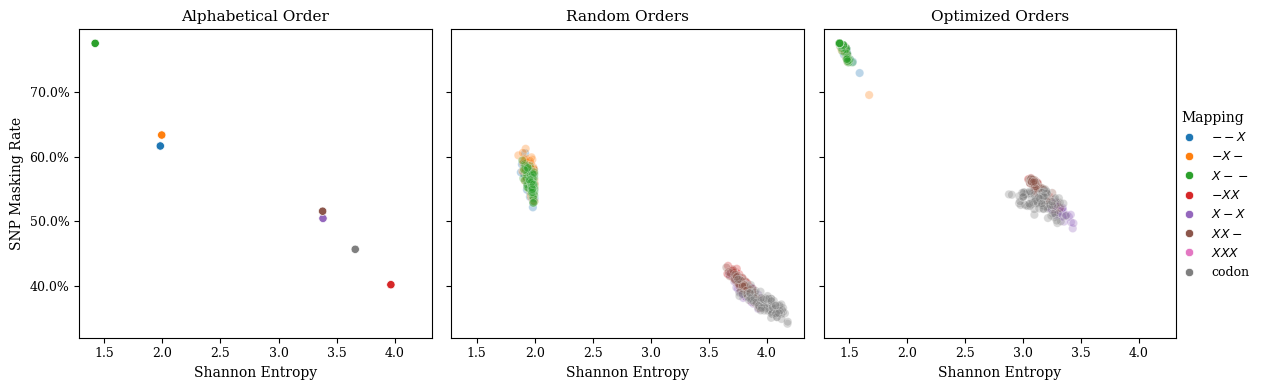

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

hue_order = ['001', '010', '100', '011', '101', '110', '111', 'codon']
custom_labels = [r'$--X$', r'$-X-$', r'$X--$', r'$-XX$', r'$X-X$', r'$XX-$', r'$XXX$', 'codon']

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Times"],
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

fig, ax = plt.subplots(1, 3, figsize=(13, 4), sharey=True, sharex=True)

# 1. Enable legend on the first plot just to capture the handles
sns.scatterplot(data=alphabetical, x='entropy', y='global_masking_rate', hue='mapping', 
                ax=ax[0], hue_order=hue_order, legend='brief')

# 2. Get the handles and labels, then remove the legend from ax[0]
handles, labels = ax[0].get_legend_handles_labels()
ax[0].get_legend().remove()

# 3. Plot the others without internal legends
sns.scatterplot(data=filtered_results_random, x='entropy', y='global_masking_rate', hue='mapping', 
                alpha=0.3, ax=ax[1], hue_order=hue_order, legend=False)
sns.scatterplot(data=filtered_results_optimized, x='entropy', y='global_masking_rate', hue='mapping', 
                alpha=0.3, ax=ax[2], hue_order=hue_order, legend=False)

# 4. Format Y-axis as Percentage (multiplies by 100 and adds %)
for a in ax:
    a.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    a.set_xlabel('Shannon Entropy')

ax[0].set_ylabel('SNP Masking Rate')
ax[0].set_title('Alphabetical Order')
ax[1].set_title('Random Orders')
ax[2].set_title('Optimized Orders')

# 5. Create the global legend
fig.legend(handles, custom_labels, title='Mapping', loc='center left', bbox_to_anchor=(0.9, 0.5), frameon=False)

plt.tight_layout(rect=[0, 0, 0.92, 1])

plt.savefig('order_performance_scatter.png', dpi=300, bbox_inches='tight')
plt.savefig('order_performance_scatter.pdf', dpi=300, bbox_inches='tight')
plt.savefig('order_performance_scatter.svg', dpi=300, bbox_inches='tight')

plt.show()

